In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
dataset=pd.read_csv("data1.csv")
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [40]:
dataset["mood_binary"] = dataset["mood_index"].apply(lambda x: 1 if x > 0.85 else 0)
X = dataset.drop(columns=["mood_index", "mood_binary"])
y = dataset["mood_binary"]

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train)
print(X_test)
print(y_train)
print(y_test)


       rating  net_payable  work_hours  leave_days  risk_score  \
49728       2        71069         482           2        0.37   
11375       4        31662         495           3        0.55   
68000       3        59939         508           4        0.53   
109         2        53773         509           4        0.51   
36034       5        54452         486           3        0.38   
...       ...          ...         ...         ...         ...   
6265        1        32693         480           3        0.30   
54886       2        32252         481           3        0.51   
76820       4        55415         501           4        0.56   
860         2        59804         485           4        0.42   
15795       2        25614         497           2        0.67   

       promotion_recommendations  predicted_growth_years  
49728                          1                       3  
11375                          0                       1  
68000                         

In [42]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
print(X_train)
print(X_test)

[[-5.64111286e-01  1.28678140e+00 -1.48018051e+00 ... -1.00840969e+00
   1.13044261e+00  5.11409829e-02]
 [ 9.02189682e-01 -1.00117242e+00 -2.42290342e-02 ...  1.27138012e-01
  -8.84609258e-01 -1.35238698e+00]
 [ 1.69039198e-01  6.40578288e-01  1.43172244e+00 ...  9.66044358e-04
  -8.84609258e-01  1.45466895e+00]
 ...
 [ 9.02189682e-01  3.77916753e-01  6.47748568e-01 ...  1.90223995e-01
   1.13044261e+00  1.45466895e+00]
 [-5.64111286e-01  6.32740245e-01 -1.14419170e+00 ... -6.92979776e-01
   1.13044261e+00 -6.50622999e-01]
 [-5.64111286e-01 -1.35231676e+00  1.99763500e-01 ...  8.84169816e-01
  -8.84609258e-01 -6.50622999e-01]]
[[-1.29726177  1.02545524 -1.1441917  ... -1.51309756 -0.88460926
   1.45466895]
 [-1.29726177 -0.63022977 -0.4722141  ...  0.37948195 -0.88460926
   1.45466895]
 [ 1.63534017 -0.0139854  -1.25618797 ...  1.19959973 -0.88460926
   0.75290497]
 ...
 [ 0.90218968 -1.04512352  0.31175977 ...  1.57811564  1.13044261
   0.75290497]
 [ 1.63534017 -0.3973528  -1.032195

In [43]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
classifier.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [44]:
from sklearn.metrics import confusion_matrix,accuracy_score
y_pred=classifier.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[12644   544]
 [  842  3243]]


0.9197591616974469

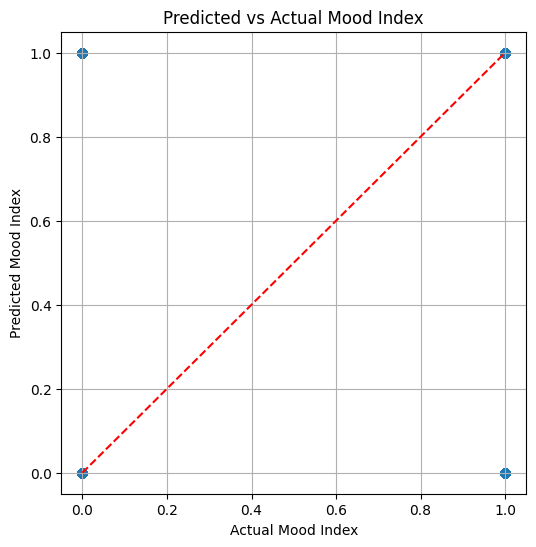

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel("Actual Mood Index")
plt.ylabel("Predicted Mood Index")
plt.title("Predicted vs Actual Mood Index")
plt.grid(True)
plt.show()